In [1]:
# Run surrogate predictions

from gpPredict import *
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import os

import pickle

from run_column_model import *

# Load pickle file with logistic regression
with open('log_reg_model.pkl', 'rb') as f:
    failure_mode_selection = pickle.load(f)
    # First parameter is the aspect ratio
    # Second parameter is Vp/Vs

    # Codes:
    # 0 = Flexure
    # 1 = Shear

In [2]:
# ndParams = ['ar', 'lrr', 'srr', 'alr', 'sdr', 'smr']
# ndParams = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

def get_BW_params(ndParams):

    # Define the failure mode using the logistic regression model
    failure_mode = failure_mode_selection.predict(np.array([[ndParams[0], ndParams[5]]]))[0]

    # Define the surrogate_file and input_json based on the failure mode
    if failure_mode == 0:
        print('Flexure failure mode')
        surrogate_file = os.path.join('gpModelFlexure', 'SimGpModel.json')
        input_json = os.path.join('gpModelFlexure', 'scInput.json')
    else:
        print('Shear failure mode')
        surrogate_file = os.path.join('gpModelShear', 'SimGpModel.json')
        input_json = os.path.join('gpModelShear', 'scInput.json')

    params_list = [
        ["RV_column1", ndParams[0]],
        ["RV_column2", ndParams[1]],
        ["RV_column3", ndParams[2]],
        ["RV_column4", ndParams[3]],
        ["RV_column5", ndParams[4]],
        ["RV_column6", ndParams[5]]
    ]

    output = main(params_list, [], surrogate_file, 'dummyout.out', input_json)
    
    # bw model parameters are the all the output parameters except the last one
    bw_model_params = output[0][:-1].tolist()

    # min error is the last output parameter
    min_error = float(output[0][-1])
    
    return bw_model_params, min_error


Finished... Run Time =  1.9518928527832031 sec


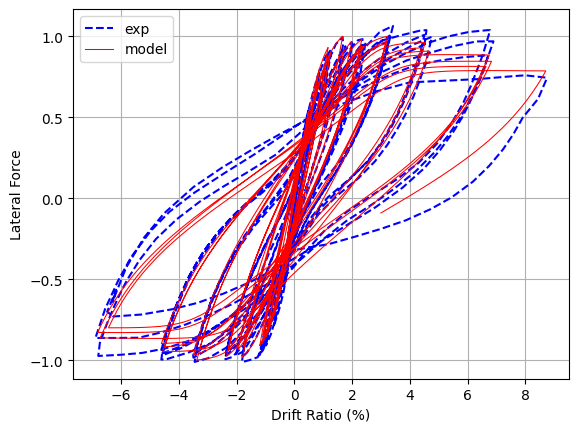

In [ ]:
# Open calibration_info.csv
calibration_info = pd.read_csv('calibration_info.csv')
calibration_info.head()

# Select one row
ii = 0

# For this row, get the bw model parameters
calParams = calibration_info[['gamma', 'kappa', 'eta1', 'sig', 'lam', 'mup', 'sigp', 'rsmax', 'alpha', 'alpha1', 'alpha2', 'betam1', 'n', 'kappa_k']].iloc[ii].values

# Get the UniqueId
UniqueId = calibration_info['UniqueId'].iloc[ii]

# Get the test_XXX.json file from test_data folder where XXX is the UniqueId

with open('test_data/test_' + str(UniqueId).zfill(3) + '.json') as f:
    test_data = json.load(f)


# Run the column model with the bw_params
run_err, interpolated_force, interpolated_displacement = run_model(test_data, bw_params, do_plots=True)